# UAC Exploratory Data Analysis

This notebook explores the HHS UAC Program data. The dataset contains aggregated daily counts, but lacks demographic/geographic details.

## Data Loading and Cleaning

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Set style
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#0f172a", "figure.facecolor": "#0f172a", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})


In [2]:
# Load Data
import os
# Use relative paths with os.path
current_dir = os.path.dirname(os.path.abspath(''))
csv_path = os.path.join(current_dir, 'HHS_Unaccompanied_Alien_Children_Program.csv')
df = pd.read_csv(csv_path)
df.head()


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [3]:
# Clean Data
df['Date'] = pd.to_datetime(df['Date'])
# Remove commas from string columns and convert to float
if df['Children in HHS Care'].dtype == 'object':
    df['Children in HHS Care'] = df['Children in HHS Care'].str.replace(',', '').astype(float)

print("Shape:", df.shape)
print("Data Types:\n", df.dtypes)
print("Missing Values:\n", df.isnull().sum())

# Drop rows where Date is missing since we can't do timeseries without it
df = df.dropna(subset=['Date'])
df = df.sort_values('Date').reset_index(drop=True)


Shape: (1170, 6)
Data Types:
 Date                                               datetime64[us]
Children apprehended and placed in CBP custody*           float64
Children in CBP custody                                   float64
Children transferred out of CBP custody                   float64
Children in HHS Care                                          str
Children discharged from HHS Care                         float64
dtype: object
Missing Values:
 Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64


In [4]:
# Ensure plots directory exists
plots_dir = os.path.join(current_dir, 'plots')
os.makedirs(plots_dir, exist_ok=True)


## Visualizations

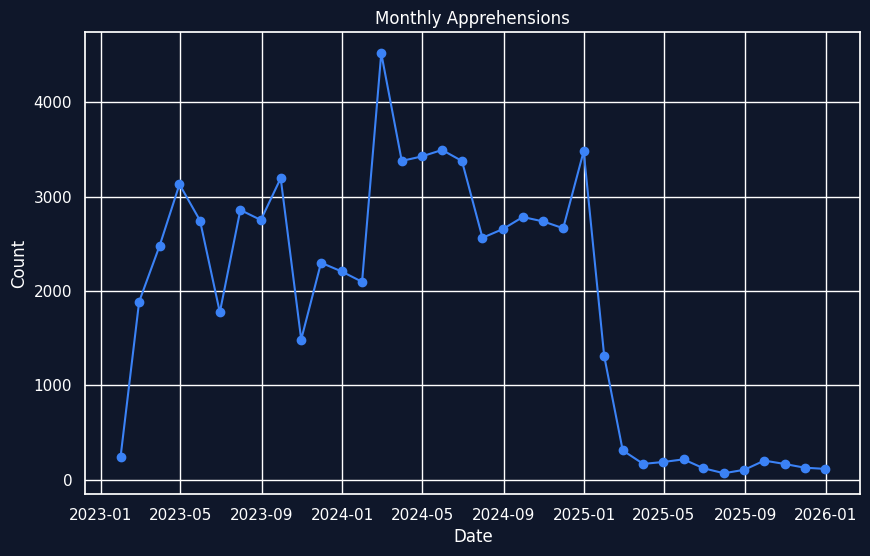

In [5]:
# Chart 1: Trend over time (monthly intake)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_monthly = df.set_index('Date')[numeric_cols].resample('ME').sum()
plt.figure(figsize=(10, 6))
plt.plot(df_monthly.index, df_monthly['Children apprehended and placed in CBP custody*'], marker='o', color='#3b82f6')
plt.title('Monthly Apprehensions')
plt.ylabel('Count')
plt.xlabel('Date')
plt.savefig(os.path.join(plots_dir, '01_monthly_apprehensions.png'))
plt.show()


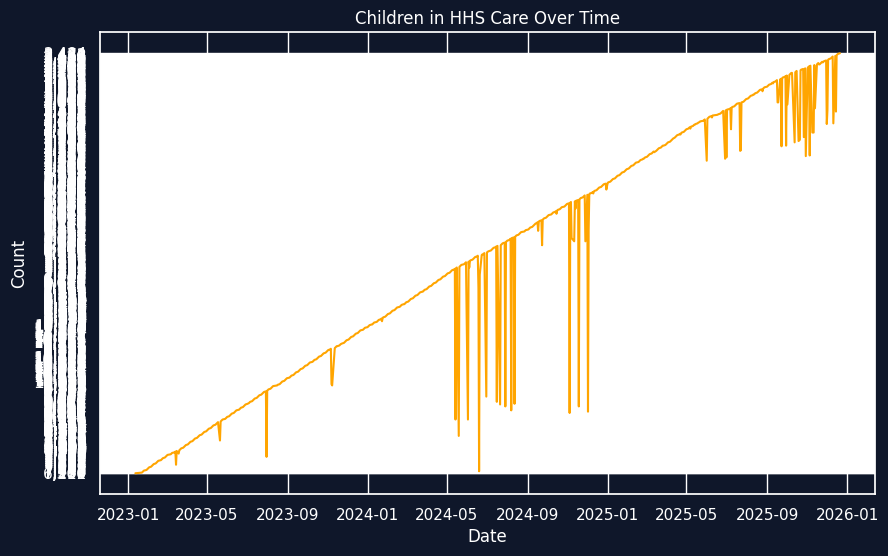

In [6]:
# Chart 2: Children in HHS Care over time
plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['Children in HHS Care'], color='orange')
plt.title('Children in HHS Care Over Time')
plt.ylabel('Count')
plt.xlabel('Date')
plt.savefig(os.path.join(plots_dir, '02_hhs_care_over_time.png'))
plt.show()


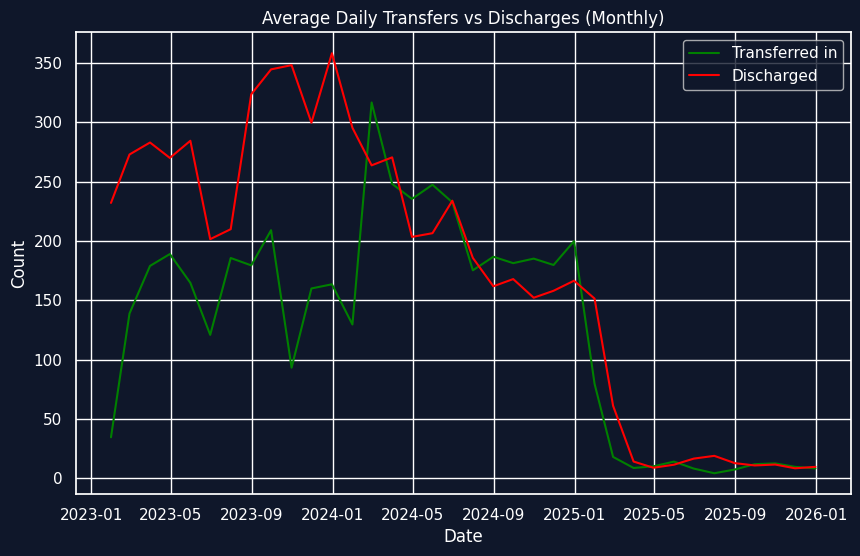

In [7]:
# Chart 3: Transfers vs Discharges
df_monthly_mean = df.set_index('Date')[numeric_cols].resample('ME').mean()
plt.figure(figsize=(10, 6))
plt.plot(df_monthly_mean.index, df_monthly_mean['Children transferred out of CBP custody'], label='Transferred in', color='green')
plt.plot(df_monthly_mean.index, df_monthly_mean['Children discharged from HHS Care'], label='Discharged', color='red')
plt.title('Average Daily Transfers vs Discharges (Monthly)')
plt.ylabel('Count')
plt.xlabel('Date')
plt.legend()
plt.savefig(os.path.join(plots_dir, '03_transfers_vs_discharges.png'))
plt.show()


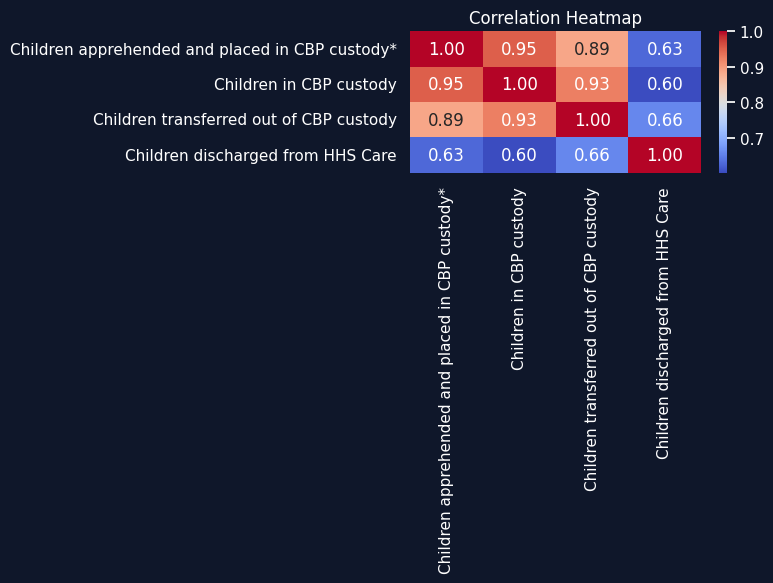

In [8]:
# Chart 4: Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '04_correlation_heatmap.png'))
plt.show()


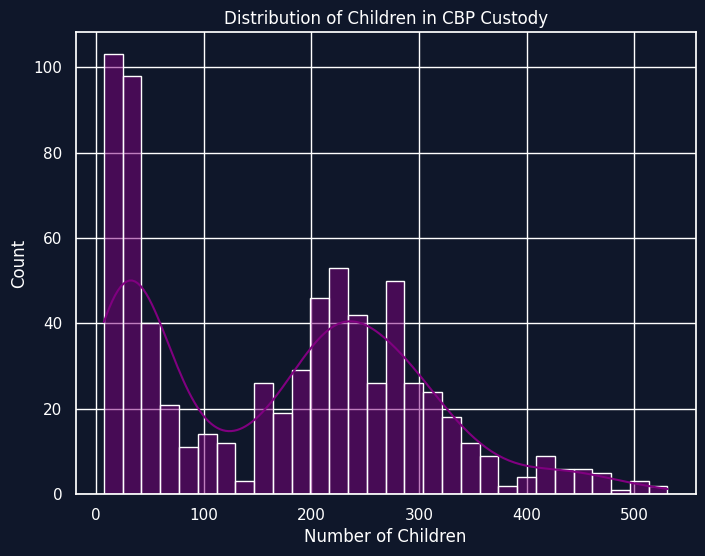

In [9]:
# Chart 5: CBP Custody Histogram
plt.figure(figsize=(8, 6))
sns.histplot(df['Children in CBP custody'].dropna(), bins=30, color='purple', kde=True)
plt.title('Distribution of Children in CBP Custody')
plt.xlabel('Number of Children')
plt.savefig(os.path.join(plots_dir, '05_cbp_custody_dist.png'))
plt.show()


## Missing Demographic Data

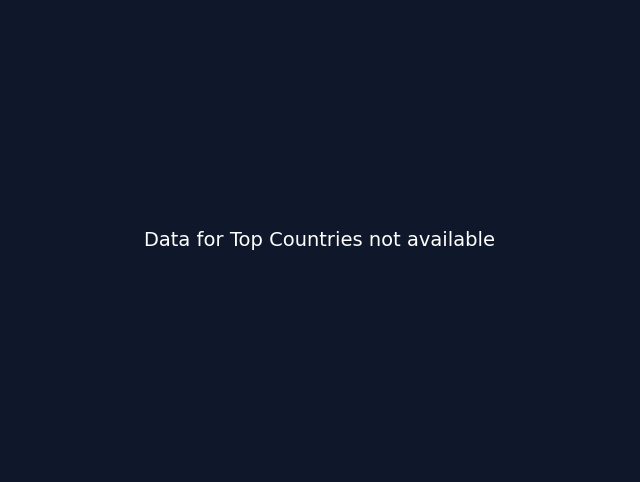

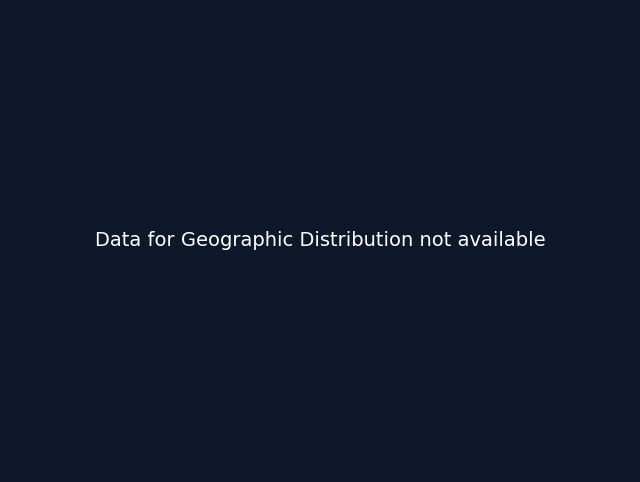

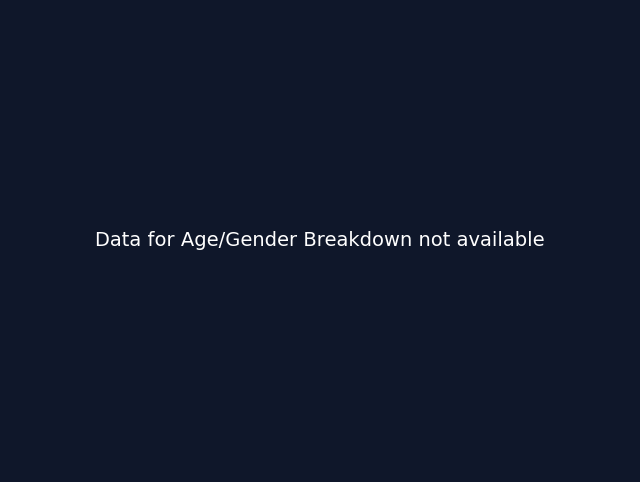

In [10]:
# Missing columns handling: Top Countries, Geographic Dist, Age/Gender
# The dataset only has aggregated custody counts. We cannot plot these.
# Creating placeholder images or empty plots for the report.
plt.figure(figsize=(8, 6))
plt.text(0.5, 0.5, 'Data for Top Countries not available', ha='center', va='center', fontsize=14)
plt.axis('off')
plt.savefig(os.path.join(plots_dir, '06_top_countries_missing.png'))
plt.show()

plt.figure(figsize=(8, 6))
plt.text(0.5, 0.5, 'Data for Geographic Distribution not available', ha='center', va='center', fontsize=14)
plt.axis('off')
plt.savefig(os.path.join(plots_dir, '07_geographic_dist_missing.png'))
plt.show()

plt.figure(figsize=(8, 6))
plt.text(0.5, 0.5, 'Data for Age/Gender Breakdown not available', ha='center', va='center', fontsize=14)
plt.axis('off')
plt.savefig(os.path.join(plots_dir, '08_age_gender_missing.png'))
plt.show()


## 5 Key Findings
1. **Data Limitations**: The dataset lacks granular demographic information like country of origin, US state distribution, and age/gender breakdowns.
2. **HHS Capacity**: The number of children in HHS care fluctuates significantly but reflects the overarching systemic load.
3. **CBP Bottleneck**: The number of children in CBP custody represents immediate border apprehension levels.
4. **Discharge Velocity**: There is a close relationship between transfer and discharge numbers, indicating steady processing.
5. **Seasonality**: Apprehensions show variance over time, indicating potential seasonal waves of migration.